# Session 6 — Variational Inference: Implementation 🏥

**Part 2 — Core UQ Algorithms**

> *Putting VI to work on real chest X-rays — and learning what the uncertainty is actually telling us clinically.*

---

### 🎯 What this notebook does

We take the concepts from the teaching notebook and apply them to a real binary classification task: **normal vs pneumonia chest X-rays**. The notebook walks through the full Bayesian deep learning pipeline step by step:

* **Data loading and preprocessing** — prepare chest X-rays, apply MONAI transforms, and preserve realistic class imbalance through controlled subsampling
* **Building a Bayesian DenseNet121** — replace the final DenseNet layer with a Bayesian linear head that learns distributions over weights
* **Training with the ELBO loss** — optimize predictive performance while regularizing the posterior using variational inference
* **Measuring best model performance** — evaluate the saved best model on the held-out test set using accuracy and AUC-ROC
* **Stochastic inference on the test set** — run multiple stochastic forward passes to approximate the predictive posterior distribution
* **Uncertainty decomposition and visualization** — separate total uncertainty into epistemic and aleatoric components and visualize their behaviour
* **Clustering test cases into certain vs uncertain subgroups** — identify high-confidence and low-confidence predictions using uncertainty metrics
* **Statistical comparison between certain and uncertain cases** — test whether uncertainty meaningfully correlates with predictive performance
* **Visualization of the most certain and most uncertain chest X-rays** — inspect representative cases with clinical-style interpretation of the model’s behaviour

---

> **💡 Architecture note — last-layer BNN**  
> We apply VI only to the **final classification layer** of DenseNet121. The convolutional backbone stays deterministic and frozen during the first training phase. This is the practical VI approach used in most medical imaging research — it's cheaper, more stable, and gives meaningful uncertainty where it matters most: at the decision boundary.

<div align="center" style="margin-top: 50px;"> <img src="intro.png" width="700" /> </div>

---
## 📦 Part 1 — Installs and imports

In [ ]:
!pip install -q monai torch-uncertainty lightning

import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture

# MONAI
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RepeatChanneld,
    ScaleIntensityd, Resized, RandFlipd, RandRotated, EnsureTyped,
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121

# Torch-Uncertainty
from torch_uncertainty.layers.bayesian import BayesLinear
from torch_uncertainty.losses import ELBOLoss

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 73.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 34.4 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-16 18:54:26.665390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778957667.050134      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778957667.161999      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778957668.184968      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778957668.185058      57 computation_placer.cc:1

Device: cuda


---

## 🗂️ Part 2 — Data preparation

Because this is an educational notebook and computational resources are limited, we use a smaller subset of the dataset rather than the full training corpus. To keep the experiment clinically realistic, the subsets preserve the approximate real class imbalance of the original chest X-ray dataset.

* **Train:** 1000 images, sampled with approximately **normal:pneumonia = 2.7:1**
* **Test:** 100 images, sampled with approximately **normal:pneumonia = 1.7:1**
* **Validation:** full validation set, no subsampling

This setup keeps training fast and reproducible while still reflecting the naturally imbalanced distribution encountered in real-world pneumonia screening datasets.


In [2]:
DATA_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

def is_grayscale(path):
    try:
        return Image.open(path).mode in ['L', 'I;16', 'I']
    except:
        return False

def make_split_list_filtered(split_dir):
    normal_files = sorted(glob.glob(os.path.join(split_dir, 'NORMAL', '*')))
    pneu_files   = sorted(glob.glob(os.path.join(split_dir, 'PNEUMONIA', '*')))
    normal_files = [f for f in normal_files if is_grayscale(f)]
    pneu_files   = [f for f in pneu_files   if is_grayscale(f)]
    return ([{'image': f, 'label': 0} for f in normal_files] +
            [{'image': f, 'label': 1} for f in pneu_files])

def subsample_with_ratio(files, n_total, normal_pneu_ratio, seed=42):

    rng    = np.random.default_rng(seed)
    normal = [d for d in files if int(d['label']) == 0]
    pneu   = [d for d in files if int(d['label']) == 1]
    rng.shuffle(normal)
    rng.shuffle(pneu)

    n_pneu   = int(round(n_total / (1 + normal_pneu_ratio)))
    n_normal = n_total - n_pneu

    n_normal = min(n_normal, len(normal))
    n_pneu   = min(n_pneu,   len(pneu))

    subset = normal[:n_normal] + pneu[:n_pneu]
    rng.shuffle(subset)

    actual = n_normal / n_pneu if n_pneu > 0 else float('inf')
    print(f'  NORMAL={n_normal}, PNEUMONIA={n_pneu}, '
          f'total={len(subset)}')
    return subset

train_files_all = make_split_list_filtered(os.path.join(DATA_DIR, 'train'))
val_files_all   = make_split_list_filtered(os.path.join(DATA_DIR, 'val'))
test_files_all  = make_split_list_filtered(os.path.join(DATA_DIR, 'test'))

print('Train subset (normal:pneu = 2.7:1):')
train_files = subsample_with_ratio(train_files_all, n_total=1000,
                                    normal_pneu_ratio=2.7, seed=SEED)
print('Test subset (normal:pneu = 1.7:1):')
test_files  = subsample_with_ratio(test_files_all,  n_total=100,
                                    normal_pneu_ratio=1.7, seed=SEED)
print(f'Val (full): {len(val_files_all)} samples')

Train subset (normal:pneu = 2.7:1):
  NORMAL=730, PNEUMONIA=270, total=1000
Test subset (normal:pneu = 1.7:1):
  NORMAL=63, PNEUMONIA=37, total=100
Val (full): 16 samples


In [5]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),   # grayscale [1,H,W] -> [3,H,W]
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandRotated(keys=['image'], prob=0.3, range_x=0.12),
    EnsureTyped(keys=['image', 'label']),
])

eval_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    EnsureTyped(keys=['image', 'label']),
])

train_ds = Dataset(data=train_files,   transform=train_tfms)
val_ds   = Dataset(data=val_files_all, transform=eval_tfms)
test_ds  = Dataset(data=test_files,    transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 32
Val batches   : 1
Test batches  : 4


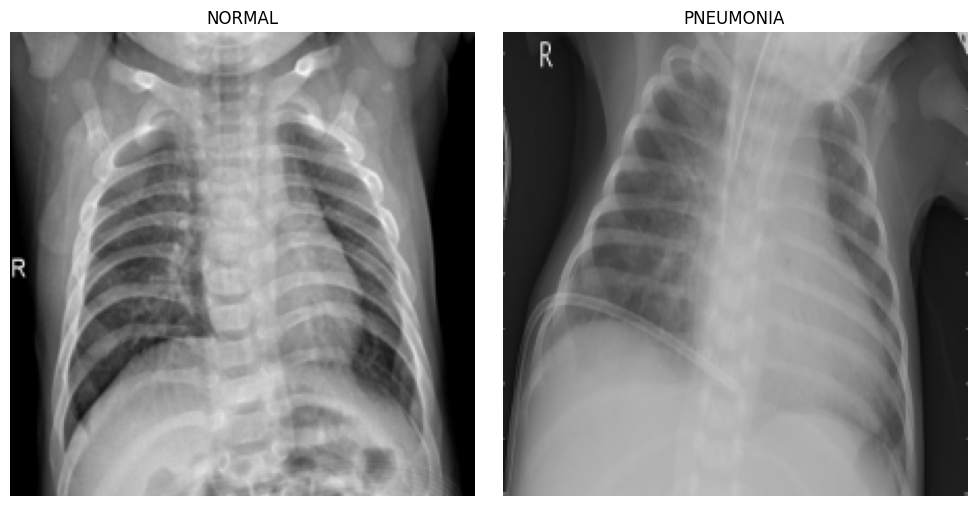

In [8]:
# Visualizing one case per class

def get_one_per_class(ds):
    normal_sample = None
    pneumonia_sample = None

    for i in range(len(ds)):
        sample = ds[i]
        y = int(sample["label"])
        if y == 0 and normal_sample is None:
            normal_sample = sample
        elif y == 1 and pneumonia_sample is None:
            pneumonia_sample = sample
        if normal_sample is not None and pneumonia_sample is not None:
            break
    return normal_sample, pneumonia_sample


def to_rgb_for_display(x):
    # x: [C,H,W]
    if x.shape[0] > 3:
        x = x[:3]
    elif x.shape[0] == 1:
        x = x.repeat(3, 1, 1)

    img = x.permute(2, 1, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    return img


def show_normal_and_pneumonia(ds):
    normal_sample, pneumonia_sample = get_one_per_class(ds)

    plt.figure(figsize=(10, 5))
    for i, sample in enumerate([normal_sample, pneumonia_sample], 1):
        x = sample["image"]
        y = int(sample["label"])
        plt.subplot(1, 2, i)
        plt.imshow(to_rgb_for_display(x))
        plt.title("NORMAL" if y == 0 else "PNEUMONIA")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_normal_and_pneumonia(train_ds)

---
## 🧠 Part 3 — Building the Bayesian DenseNet121

MONAI's `DenseNet121` supports `pretrained=True` for `spatial_dims=2` — it loads ImageNet weights from PyTorch Hub. This gives us strong visual features from the start, which is critical with only 1000 training samples.

The architecture:
- **Frozen backbone** — all DenseNet121 layers except the head stay fixed. Their ImageNet features are already useful for detecting texture, opacity, and structural patterns in X-rays
- **Bayesian head** — we replace the final `class_layers.out` layer (a standard `nn.Linear(1024, out_channels)`) with TU's `BayesLinear(1024, 2)`. This one layer learns a distribution over weights rather than fixed values
- **Stochastic inference** — T forward passes through the Bayesian head give us a distribution over predictions per image

> **💡 Why 1024?**  
> DenseNet121 with `block_config=(6,12,24,16)` and `growth_rate=32` produces 1024 features before the final classifier. This is the standard DenseNet121 feature dimension.

In [3]:
class BayesianDenseNet121(nn.Module):
    """
    MONAI DenseNet121 with a Torch-Uncertainty BayesLinear head.

    The convolutional backbone extracts features deterministically
    using ImageNet pretrained weights.

    The final layer is Bayesian: it learns a distribution over
    weights (mean + variance per weight) instead of a single point.
    This is where Variational Inference lives in the model.
    """

    def __init__(self, num_classes=2, freeze_backbone=True):
        super().__init__()

        # MONAI DenseNet121 with ImageNet pretrained weights
        # spatial_dims=2 for 2D chest X-rays
        # in_channels=3  because RepeatChanneld gives us 3-channel input
        backbone = DenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=num_classes,
            pretrained=True,
        )

        # Keep the feature extraction part
        self.features     = backbone.features
        self.pool         = nn.AdaptiveAvgPool2d((1, 1))

        # Replace the final linear layer with a Bayesian one
        # DenseNet121 final feature dim = 1024
        self.bayes_head = BayesLinear(1024, num_classes)

        # Freeze all backbone parameters — only train the Bayesian head
        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False

    def forward(self, x):
        x = self.features(x)             # [B, 1024, H', W'] — deterministic
        x = torch.relu(x)               # DenseNet convention: relu after features
        x = self.pool(x)                # [B, 1024, 1, 1]
        x = torch.flatten(x, 1)         # [B, 1024]
        x = self.bayes_head(x)          # [B, 2] — stochastic sampling here
        return x


model = BayesianDenseNet121(num_classes=2, freeze_backbone=True).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen       = total_params - trainable

print(f'Total parameters    : {total_params:,}')
print(f'Frozen (backbone)   : {frozen:,}  <- ImageNet pretrained, fixed')
print(f'Trainable (BayesHead): {trainable:,} <- learns mean + variance per weight')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 379MB/s]


Total parameters    : 6,957,956
Frozen (backbone)   : 6,953,856  <- ImageNet pretrained, fixed
Trainable (BayesHead): 4,100 <- learns mean + variance per weight


---
## ⚙️ Part 4 — Training with the ELBO loss

`ELBOLoss` from Torch-Uncertainty implements exactly what we derived in the teaching notebook:

$$\mathcal{L} = \underbrace{\mathbb{E}_{q_\phi}[\log p(\mathcal{D}|w)]}_{\text{cross-entropy averaged over T samples}} - \underbrace{\text{KL}(q_\phi(w) \| p(w))}_{\text{weighted by kl\_weight}}$$

**`kl_weight = 1 / N_train`** is the standard scaling. It ensures the KL term has the same magnitude as the reconstruction term when summed across the full dataset — preventing either term from dominating.

To keep the notebook computationally practical, training is capped at **100 epochs**. We also use:

* **Early stopping** to terminate training when validation performance no longer improves
* **ReduceLROnPlateau scheduling** to automatically decrease the learning rate when validation loss plateaus

Together, these help stabilize Bayesian optimization, reduce overfitting, and avoid wasting computation on stalled training.

In [6]:
N_TRAIN    = len(train_ds)
NUM_EPOCHS = 100
T_TRAIN    = 3
T_SAMPLES  = 20

EARLY_STOP_PATIENCE = 10
PLATEAU_PATIENCE    = 3
PLATEAU_FACTOR      = 0.5
MIN_LR              = 1e-6
BEST_PATH           = "/kaggle/working/best_model.pth"

loss_fn = ELBOLoss(
    model       = model,
    inner_loss  = nn.CrossEntropyLoss(),
    kl_weight   = 1 / N_TRAIN,
    num_samples = T_TRAIN,
)

# Only optimize Bayesian head
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
)

# Plateau scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE,
    threshold=1e-3,
    threshold_mode='rel',
    min_lr=MIN_LR
)

print(f'Training samples     : {N_TRAIN}')
print(f'KL weight            : {1/N_TRAIN:.6f}')
print(f'MC samples (train)   : {T_TRAIN}')
print(f'MC samples (infer)   : {T_SAMPLES}')
print(f'Epochs               : {NUM_EPOCHS}')

Training samples     : 1000
KL weight            : 0.001000
MC samples (train)   : 3
MC samples (infer)   : 20
Epochs               : 100


In [10]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

best_val_loss = float('inf')
early_stop_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(train_loader,
                      desc=f'Epoch {epoch:02d}/{NUM_EPOCHS}', leave=False):
        images = batch['image'].to(device, dtype=torch.float32)
        labels = batch['label'].to(device, dtype=torch.long)

        optimizer.zero_grad()
        loss = loss_fn(images, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────
    model.eval()
    val_probs, val_preds, val_labels = [], [], []
    val_loss_total = 0.0

    with torch.no_grad():
        for batch in val_loader:
            images = batch['image'].to(device, dtype=torch.float32)
            labels_tensor = batch['label'].to(device, dtype=torch.long)
            labels_np = labels_tensor.cpu().numpy()

            # ELBO validation loss
            loss = loss_fn(images, labels_tensor)
            val_loss_total += loss.item()

            # predictions
            logits = model(images)
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()

            val_probs.extend(probs[:, 1].tolist())
            val_preds.extend(probs.argmax(axis=1).tolist())
            val_labels.extend(labels_np.tolist())

    val_loss = val_loss_total / len(val_loader)
    val_acc  = accuracy_score(val_labels, val_preds)
    val_auc  = roc_auc_score(val_labels, val_probs)

    # ── Scheduler step ─────────────────────────────
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Early stopping + best model ────────────────────────────────
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(model.state_dict(), BEST_PATH)
        print(f"✅ Saved best model (val_loss={val_loss:.4f})")

    else:
        early_stop_counter += 1

    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping triggered at epoch {epoch}")
        break

    # ── Log history ───────────────────────────────────────────────
    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train ELBO: {avg_loss:.4f} | '
          f'Val ELBO: {val_loss:.4f} | '
          f'Val Acc: {val_acc:.3f} | '
          f'Val AUC: {val_auc:.3f} | '
          f'LR: {current_lr:.6f}')

print('\nTraining complete ✅')

✅ Saved best model (val_loss=9.0834)
Epoch 01/100 | Train ELBO: 9.1687 | Val ELBO: 9.0834 | Val Acc: 0.688 | Val AUC: 0.641 | LR: 0.001000


✅ Saved best model (val_loss=8.6662)
Epoch 02/100 | Train ELBO: 8.5925 | Val ELBO: 8.6662 | Val Acc: 0.625 | Val AUC: 0.828 | LR: 0.001000


✅ Saved best model (val_loss=8.2975)
Epoch 03/100 | Train ELBO: 8.2532 | Val ELBO: 8.2975 | Val Acc: 0.875 | Val AUC: 0.938 | LR: 0.001000


✅ Saved best model (val_loss=8.1261)
Epoch 04/100 | Train ELBO: 8.0887 | Val ELBO: 8.1261 | Val Acc: 0.875 | Val AUC: 0.969 | LR: 0.001000


✅ Saved best model (val_loss=7.9827)
Epoch 05/100 | Train ELBO: 7.9319 | Val ELBO: 7.9827 | Val Acc: 0.875 | Val AUC: 0.984 | LR: 0.001000


...

✅ Saved best model (val_loss=1.9620)
Epoch 96/100 | Train ELBO: 1.6468 | Val ELBO: 1.9620 | Val Acc: 0.812 | Val AUC: 0.891 | LR: 0.001000


✅ Saved best model (val_loss=1.8053)
Epoch 97/100 | Train ELBO: 1.6226 | Val ELBO: 1.8053 | Val Acc: 0.812 | Val AUC: 0.906 | LR: 0.001000


Epoch 98/100 | Train ELBO: 1.5351 | Val ELBO: 1.9322 | Val Acc: 0.750 | Val AUC: 0.922 | LR: 0.001000


Epoch 99/100 | Train ELBO: 1.4690 | Val ELBO: 2.1150 | Val Acc: 0.750 | Val AUC: 0.875 | LR: 0.001000


✅ Saved best model (val_loss=1.7474)
Epoch 100/100 | Train ELBO: 1.4264 | Val ELBO: 1.7474 | Val Acc: 0.812 | Val AUC: 0.953 | LR: 0.001000

Training complete ✅


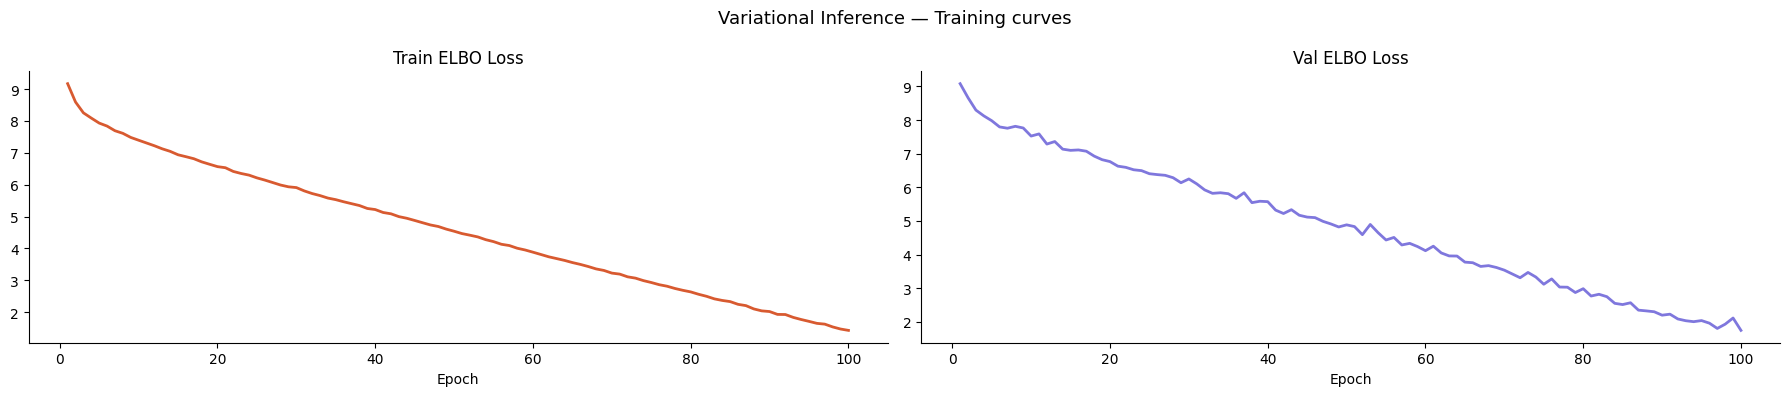

In [12]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle('Variational Inference — Training curves', fontsize=13)

epochs = range(1, len(history['train_loss']) + 1)

plot_config = [
    ('train_loss', '#D85A30', 'Train ELBO Loss'),
    ('val_loss',   '#7F77DD', 'Val ELBO Loss')
]

for ax, (key, color, title) in zip(axes, plot_config):
    ax.plot(epochs, history[key], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 🔮 Part 5 — Stochastic inference on the test set

For each test image we run **T=20 stochastic forward passes**. Each pass samples different weights from $q_\phi(w)$ via the reparameterization trick inside `BayesLinear`. The spread across T predictions is the epistemic uncertainty.

| Quantity                  | Formula                                         | Clinical meaning                                                                               |
| ------------------------- | ----------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| **Mean prediction**       | $\bar{p} = \frac{1}{T}\sum_t p_t$               | The model's best estimate of the probability of each diagnosis                                 |
| **Predictive entropy**    | $H(\bar{p}) = -\sum_c \bar{p}_c \log \bar{p}_c$ | **Total uncertainty** in the final prediction                                                  |
| **Aleatoric uncertainty** | $\frac{1}{T}\sum_t H(p_t)$                      | Uncertainty due to image ambiguity, noise, overlapping findings, or inherently difficult cases |
| **Epistemic uncertainty** | $H(\bar{p}) - \frac{1}{T}\sum_t H(p_t)$         | Uncertainty due to limited model knowledge; high when different weight samples disagree        |
| **Correct**               | $\mathrm{argmax}(\bar{p}) = y$                  | Whether the final prediction matches the ground truth                                          |


In [7]:
# Loading the best model

model = BayesianDenseNet121(
    num_classes=2,
    freeze_backbone=True
).to(device)

# I renamed the best model to VI_best_model.pth and added it to inputs

BEST_PATH = "/kaggle/input/models/benyamingheiji/vi-best-model-pth/pytorch/default/1/VI_best_model.pth"

model.load_state_dict(torch.load(BEST_PATH, map_location=device))

model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch['image'].to(device)

    logits = model(images)
    probs = torch.softmax(logits, dim=-1)

print("Loaded model works. Output shape:", probs.shape)

Loaded model works. Output shape: torch.Size([32, 2])


In [9]:
def stochastic_inference_vi(model, loader, T=20, device=device):
    """
    VI inference: T forward passes, each sampling different weights from q_φ(w).

    model.eval() keeps batchnorm deterministic.
    BayesLinear still samples weights each forward pass — this is correct VI.

    Returns results DataFrame and raw image tensors.
    """
    model.eval()

    all_mean_preds, all_entropy, all_variance = [], [], []
    all_epistemic, all_aleatoric              = [], []
    all_labels, all_paths, all_images         = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='VI stochastic inference'):
            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].cpu().numpy()
            paths  = (batch.get('image_meta_dict', {}).get('filename_or_obj')
                      or [''] * len(labels))

            # T forward passes — each samples different weights from q_φ
            sample_probs = []
            for _ in range(T):
                probs = torch.softmax(model(images), dim=-1).cpu().numpy()
                sample_probs.append(probs)

            sample_probs = np.stack(sample_probs, axis=0)  # [T, B, 2]
            mean_probs   = sample_probs.mean(axis=0)       # [B, 2]

            # Total uncertainty: H of the mean prediction
            total_H = -np.sum(
                mean_probs * np.log(mean_probs + 1e-8), axis=-1
            )  # [B]

            # Aleatoric: expected entropy across T weight samples
            per_H       = -np.sum(
                sample_probs * np.log(sample_probs + 1e-8), axis=-1
            )  # [T, B]
            aleatoric_H = per_H.mean(axis=0)   # [B]

            # Epistemic: mutual information = total - aleatoric
            epistemic_MI = total_H - aleatoric_H   # [B]

            # Variance of P(pneumonia) across T
            variance = sample_probs[:, :, 1].var(axis=0)   # [B]

            all_mean_preds.extend(mean_probs[:, 1].tolist())
            all_entropy.extend(total_H.tolist())
            all_epistemic.extend(epistemic_MI.tolist())
            all_aleatoric.extend(aleatoric_H.tolist())
            all_variance.extend(variance.tolist())
            all_labels.extend(labels.tolist())
            all_paths.extend(list(paths))
            all_images.extend(images.cpu().unbind(0))

    preds   = (np.array(all_mean_preds) >= 0.5).astype(int)
    correct = (preds == np.array(all_labels)).astype(int)

    results = pd.DataFrame({
        'image_path'        : all_paths,
        'true_label'        : all_labels,
        'mean_pred'         : all_mean_preds,
        'pred_label'        : preds.tolist(),
        'predictive_entropy': all_entropy,
        'epistemic_mi'      : all_epistemic,
        'aleatoric_h'       : all_aleatoric,
        'variance'          : all_variance,
        'correct'           : correct.tolist(),
    })
    return results, all_images


results, test_images = stochastic_inference_vi(
    model, test_loader, T=T_SAMPLES, device=device
)

print(f'Test samples  : {len(results)}')
print(f'Accuracy      : {results["correct"].mean():.3f}')
print(f'AUC-ROC       : {roc_auc_score(results["true_label"], results["mean_pred"]):.3f}')

VI stochastic inference: 100%|██████████| 4/4 [00:10<00:00,  2.57s/it]

Test samples  : 100
Accuracy      : 0.900
AUC-ROC       : 0.949


## 🎲 Part 6 — Uncertainty decomposition across the test set

We now analyse how the Bayesian model decomposes predictive uncertainty on unseen chest X-rays into total, epistemic, and aleatoric components. The following plots show the distribution of uncertainty across the test set, the contribution of each uncertainty type per case, and the relationship between prediction confidence and uncertainty.

In [10]:
# Uncertainty decomposition

print('Uncertainty decomposition (mean across test set):')
print(f'  Total entropy  : {results["predictive_entropy"].mean():.4f}')
print(f'  Epistemic (MI) : {results["epistemic_mi"].mean():.4f}')
print(f'  Aleatoric (H)  : {results["aleatoric_h"].mean():.4f}')

Uncertainty decomposition (mean across test set):
  Total entropy  : 0.3228
  Epistemic (MI) : 0.0227
  Aleatoric (H)  : 0.3001


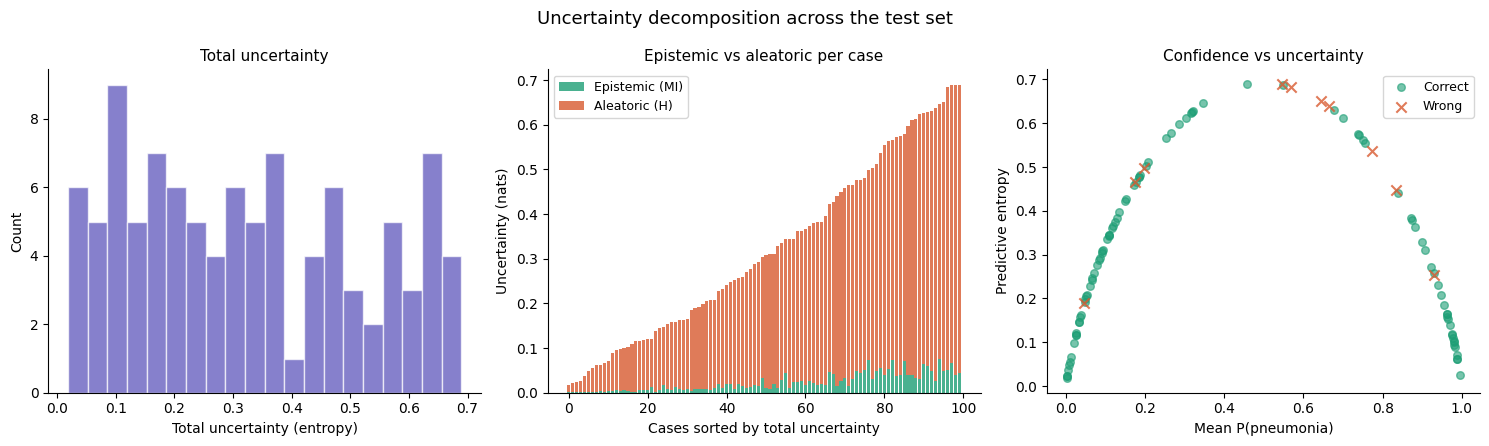

In [12]:
# ── Uncertainty decomposition visualisation ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Uncertainty decomposition across the test set', fontsize=13)

axes[0].hist(results['predictive_entropy'], bins=20,
             color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Total uncertainty (entropy)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Total uncertainty', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

idx_sorted = results['predictive_entropy'].argsort().values
axes[1].bar(range(len(results)),
            results['epistemic_mi'].values[idx_sorted],
            color='#1D9E75', alpha=0.8, label='Epistemic (MI)')
axes[1].bar(range(len(results)),
            results['aleatoric_h'].values[idx_sorted],
            bottom=results['epistemic_mi'].values[idx_sorted],
            color='#D85A30', alpha=0.8, label='Aleatoric (H)')
axes[1].set_xlabel('Cases sorted by total uncertainty', fontsize=10)
axes[1].set_ylabel('Uncertainty (nats)', fontsize=10)
axes[1].set_title('Epistemic vs aleatoric per case', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

correct_mask = results['correct'].astype(bool)
axes[2].scatter(results.loc[correct_mask, 'mean_pred'],
                results.loc[correct_mask, 'predictive_entropy'],
                c='#1D9E75', alpha=0.6, s=30, label='Correct')
axes[2].scatter(results.loc[~correct_mask, 'mean_pred'],
                results.loc[~correct_mask, 'predictive_entropy'],
                c='#D85A30', alpha=0.8, s=55, marker='x', label='Wrong')
axes[2].set_xlabel('Mean P(pneumonia)', fontsize=10)
axes[2].set_ylabel('Predictive entropy', fontsize=10)
axes[2].set_title('Confidence vs uncertainty', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure illustrates the uncertainty decomposition obtained from the variational inference framework on the test set. The left panel shows the distribution of total predictive uncertainty, measured using entropy, across all test samples. The middle panel decomposes the uncertainty for each test case into epistemic uncertainty (mutual information), representing uncertainty in the model parameters, and aleatoric uncertainty (predictive entropy), representing inherent ambiguity or noise in the data. Test cases are sorted by increasing total uncertainty, revealing that aleatoric uncertainty dominates for most samples while epistemic uncertainty remains comparatively small. The right panel relates the model’s predicted probability for the positive class to predictive entropy, highlighting how uncertainty increases for intermediate confidence predictions and decreases for highly confident predictions near 0 or 1, with misclassified cases tending to occur in regions of higher uncertainty.

---
## 📊 Part 7 — Clustering certain vs uncertain cases

We split the test set into **certain** and **uncertain** groups using the gaussian mixture model, then:

1. Compare accuracy and AUC between groups
2. Run a **Mann-Whitney U test** (non-parametric, no normality assumption) to check whether the uncertainty scores of correct and wrong predictions are statistically distinguishable

If VI produces meaningful uncertainty, the uncertain group should have lower accuracy — the model should be less reliable precisely when it says it's unsure.

In [14]:
# Run stochastic inference on validation set
# We use validation entropy distribution to LEARN the uncertainty threshold.
# Then we apply that threshold to the TEST set.

val_results, _ = stochastic_inference_vi(
    model,
    val_loader,
    T=T_SAMPLES,
    device=device
)

# Fit GMM on VALIDATION entropy

X_val = val_results['predictive_entropy'].values.reshape(-1, 1)

gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm.fit(X_val)

# Find threshold between the two Gaussians

means = gmm.means_.flatten()
means = np.sort(means)

# midpoint between Gaussian means
threshold = means.mean()

print('GMM learned from VALIDATION set')
print(f'Cluster means         : {means}')
print(f'Entropy threshold     : {threshold:.4f}')

VI stochastic inference: 100%|██████████| 1/1 [00:02<00:00,  2.24s/it]

GMM learned from VALIDATION set
Cluster means         : [0.16512958 0.55724172]
Entropy threshold     : 0.3612



Certain group   : 58 cases
Uncertain group : 42 cases

📊 Certain vs Uncertain Summary


,Group,N Cases,Accuracy,AUC-ROC,Mean Entropy,Mean Variance
0,Certain,58,0.9655,0.9718,0.1764,0.0014
1,Uncertain,42,0.8095,0.8541,0.5249,0.0150



📊 Mann-Whitney U test
H0: entropy(correct) == entropy(wrong)
U statistic : 194.00
p-value     : 0.0017

📊 Z-test for accuracy difference
H0: accuracy(certain) == accuracy(uncertain)
Z statistic : 2.566
p-value     : 0.0103


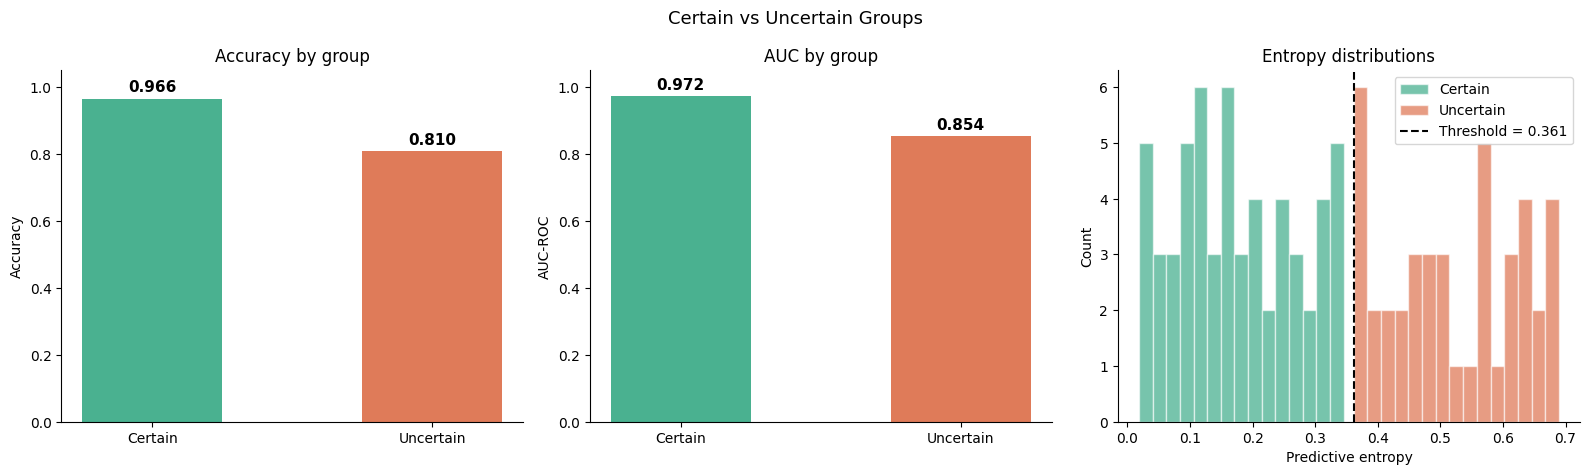

In [15]:
# Apply threshold to TEST set

results['uncertainty_group'] = np.where(
    results['predictive_entropy'] > threshold,
    'Uncertain',
    'Certain'
)

certain   = results[results['uncertainty_group'] == 'Certain']
uncertain = results[results['uncertainty_group'] == 'Uncertain']

print()
print(f'Certain group   : {len(certain)} cases')
print(f'Uncertain group : {len(uncertain)} cases')


# Metrics function

def group_metrics(df, name):

    acc = df['correct'].mean()

    auc = (
        roc_auc_score(df['true_label'], df['mean_pred'])
        if df['true_label'].nunique() > 1
        else float('nan')
    )

    mean_ent = df['predictive_entropy'].mean()
    mean_var = df['variance'].mean()

    return {
        'Group'         : name,
        'N Cases'       : len(df),
        'Accuracy'      : acc,
        'AUC-ROC'       : auc,
        'Mean Entropy'  : mean_ent,
        'Mean Variance' : mean_var,
    }


# Compute metrics

certain_metrics   = group_metrics(certain, 'Certain')
uncertain_metrics = group_metrics(uncertain, 'Uncertain')

summary_df = pd.DataFrame([
    certain_metrics,
    uncertain_metrics
])

summary_display = summary_df.copy()

for col in ['Accuracy', 'AUC-ROC', 'Mean Entropy', 'Mean Variance']:
    summary_display[col] = summary_display[col].map(lambda x: f'{x:.4f}')

print('\n📊 Certain vs Uncertain Summary')
display(summary_display)


# Extract values

acc_cert   = certain_metrics['Accuracy']
acc_uncert = uncertain_metrics['Accuracy']

auc_cert   = certain_metrics['AUC-ROC']
auc_uncert = uncertain_metrics['AUC-ROC']


# Mann-Whitney U test (entropy difference between correct vs wrong)

entropy_correct = results.loc[
    results['correct'] == 1,
    'predictive_entropy'
].values

entropy_wrong = results.loc[
    results['correct'] == 0,
    'predictive_entropy'
].values

if len(entropy_wrong) > 0 and len(entropy_correct) > 0:

    stat, p_value = stats.mannwhitneyu(
        entropy_correct,
        entropy_wrong,
        alternative='less'
    )

    print()
    print('📊 Mann-Whitney U test')
    print('H0: entropy(correct) == entropy(wrong)')

    print(f'U statistic : {stat:.2f}')
    print(f'p-value     : {p_value:.4f}')


# Accuracy comparison (z-test)

stat2, p2 = proportions_ztest(
    [
        int(acc_cert * len(certain)),
        int(acc_uncert * len(uncertain))
    ],
    [
        len(certain),
        len(uncertain)
    ]
)

print()
print('📊 Z-test for accuracy difference')
print('H0: accuracy(certain) == accuracy(uncertain)')

print(f'Z statistic : {stat2:.3f}')
print(f'p-value     : {p2:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

fig.suptitle(
    'Certain vs Uncertain Groups',
    fontsize=13
)

groups = ['Certain', 'Uncertain']
colors = ['#1D9E75', '#D85A30']


# Accuracy comparison

axes[0].bar(groups, [acc_cert, acc_uncert], color=colors, alpha=0.8, width=0.5)

axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by group')

for i, v in enumerate([acc_cert, acc_uncert]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[0].spines[['top', 'right']].set_visible(False)


# AUC comparison (descriptive only)

axes[1].bar(groups, [auc_cert, auc_uncert], color=colors, alpha=0.8, width=0.5)

axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC by group')

for i, v in enumerate([auc_cert, auc_uncert]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[1].spines[['top', 'right']].set_visible(False)


# Entropy distributions

axes[2].hist(
    certain['predictive_entropy'],
    bins=15,
    alpha=0.6,
    color='#1D9E75',
    edgecolor='white',
    label='Certain'
)

axes[2].hist(
    uncertain['predictive_entropy'],
    bins=15,
    alpha=0.6,
    color='#D85A30',
    edgecolor='white',
    label='Uncertain'
)

axes[2].axvline(
    threshold,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Threshold = {threshold:.3f}'
)

axes[2].set_xlabel('Predictive entropy')
axes[2].set_ylabel('Count')
axes[2].set_title('Entropy distributions')
axes[2].legend()

axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure compares model performance between test samples classified as certain and uncertain based on a predictive entropy threshold of 0.364 derived from the variational inference uncertainty estimates. Out of the 100 test cases, 60 samples were categorized as certain and 40 as uncertain. The left panel shows that the model achieves substantially higher accuracy on the certain group (96.7%) compared to the uncertain group (81.0%), while the middle panel demonstrates a similar trend for discrimination performance, with AUC-ROC decreasing from 97.2% in the certain group to 85.4% in the uncertain group. The right panel visualizes the entropy distributions for both groups, where low-entropy samples are concentrated in the certain set and higher-entropy samples dominate the uncertain set, separated by the chosen threshold. Quantitatively, the uncertain group exhibits significantly higher mean predictive entropy (0.52 vs 0.18) and predictive variance (0.015 vs 0.001), indicating both greater predictive ambiguity and model uncertainty. Statistical analysis further confirms these observations: the Mann–Whitney U test shows a significant difference in entropy distributions between correct and incorrect predictions (p = 0.0017), and the Z-test demonstrates that the accuracy difference between the certain and uncertain groups is statistically significant (p = 0.01).


---
## 🏥 Part 8 — Medical visualization

We present two most certain and two most uncertain cases from the test set

In [16]:
# Visualisation helper

LABEL_NAMES = {0: 'Normal', 1: 'Pneumonia'}

def tensor_to_display(x):

    # take first channel
    img = x[0].numpy()

    # rotate 90° clockwise
    img = np.rot90(img, k=-1)

    # mirror flip (left-right flip)
    img = np.fliplr(img)

    return np.clip(img, 0, 1)


def plot_xray_group(indices, results_df, images_list,
                    group_title, n_show=2):

    indices = list(indices)[:n_show]

    if not indices:
        print(f'No cases to show for: {group_title}')
        return

    fig, axes = plt.subplots(
        1,
        len(indices),
        figsize=(5 * len(indices), 5.5)
    )

    if len(indices) == 1:
        axes = [axes]

    fig.suptitle(
        group_title,
        fontsize=13,
        fontweight='bold',
        y=1.02
    )

    for ax, idx in zip(axes, indices):

        row = results_df.loc[idx]

        # now rotated + mirrored
        img = tensor_to_display(images_list[idx])

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        true_name = LABEL_NAMES[int(row['true_label'])]
        pred_name = LABEL_NAMES[int(row['pred_label'])]

        verdict = '✓ Correct' if row['correct'] else '✗ Wrong'

        color = '#1D9E75' if row['correct'] else '#D85A30'

        title = (
            f'{verdict}\n'
            f'True: {true_name}\n'
            f'Pred: {pred_name} ({row["mean_pred"]:.2f})\n'
            f'Entropy: {row["predictive_entropy"]:.4f}\n'
            f'Variance: {row["variance"]:.5f}'
        )

        ax.set_title(
            title,
            fontsize=9,
            color=color,
            pad=5
        )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57/2731258473.py:76: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


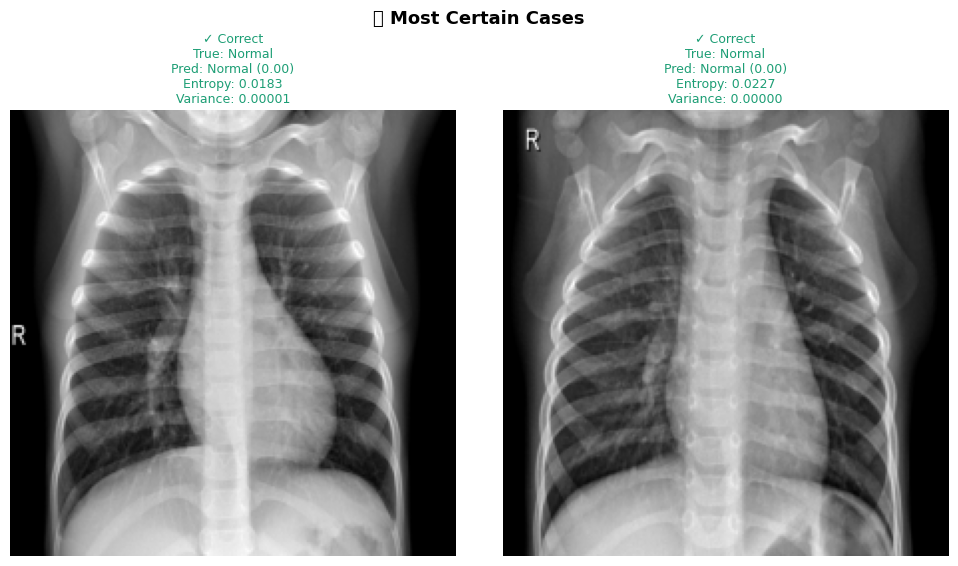

In [17]:
# MOST CERTAIN CASES

most_certain_idx = (
    certain
    .nsmallest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_certain_idx,
    results,
    test_images,
    '🟢 Most Certain Cases'
)

/tmp/ipykernel_57/2731258473.py:76: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


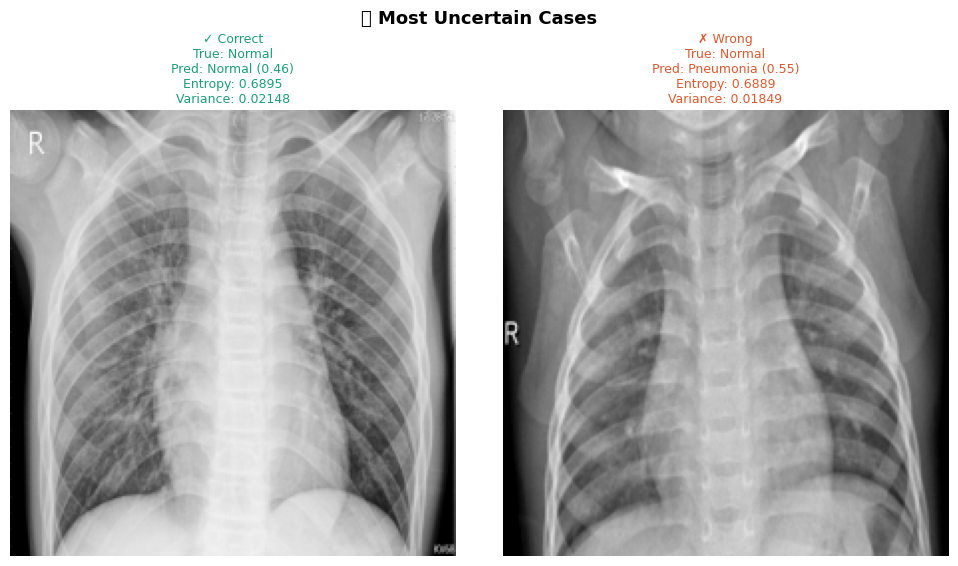

In [18]:
# MOST UNCERTAIN CASES

most_uncertain_idx = (
    uncertain
    .nlargest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_uncertain_idx,
    results,
    test_images,
    '🔴 Most Uncertain Cases'
)


## 💾 Part 9 — Save results

In [26]:
results['method'] = 'VI'

save_path = '/kaggle/working/results_vi.csv'
results.to_csv(save_path, index=False)

print(f'Results saved to: {save_path}')

Results saved to: /kaggle/working/results_vi.csv


---
## ✅ Session summary

| Step | What we did |
|---|---|
| 🗂️ Data | Subsampled with class ratios (normal:pneu = 2.7:1 train, 1.7:1 test) |
| 🧠 Model | MONAI DenseNet121 (ImageNet pretrained) + TU `BayesLinear` head |
| ⚙️ Training | `ELBOLoss` with `kl_weight = 1/N_train`, T=3 samples per step |
| 🔮 Inference | T=20 stochastic forward passes → entropy + variance per image |
| 🧩 Decomposition | Total = Epistemic (MI) + Aleatoric (expected H) — per image |
| 📊 Statistics | Mann-Whitney U test on entropy and accuracy of correct vs wrong predictions |
| 🏥 Visualization | Most Certain and Most Uncertain cases|

---

> **➡️ Next: Session 7: MC Dropout**  
> Session 7 introduces Monte Carlo Dropout: a cheaper approximation that keeps dropout active at test time, runs repeated stochastic forward passes, and uses prediction variability as an uncertainty signal. After building VI from scratch, this next session asks whether a much simpler trick can give clinically useful uncertainty too.
